In [1]:
!pip install ultralytics roboflow opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!pip install roboflow

In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="q2Nue3yODZO5IEwDwO35")

project = rf.workspace("jawhra-3li").project("face-mask-jk4nr-3grwh")

# Show available versions
print(project.versions())

loading Roboflow workspace...
loading Roboflow project...
[]


In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Path to dataset files: /kaggle/input/face-mask-detection


In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Path to dataset files: /kaggle/input/face-mask-detection


In [17]:
import os

# Your path from the previous step
path = "/kaggle/input/face-mask-detection"

# List the contents of the folder
print(os.listdir(path))

['annotations', 'images']


In [18]:
import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

# Path where your files currently are
source_path = Path("/kaggle/input/face-mask-detection")
output_path = Path("yolo_dataset")
classes = {"without_mask": 0, "with_mask": 1, "mask_weared_incorrect": 2}

# Create required directory structure
for split in ['train', 'val']:
    (output_path / f"images/{split}").mkdir(parents=True, exist_ok=True)
    (output_path / f"labels/{split}").mkdir(parents=True, exist_ok=True)

def convert_to_yolo(xml_file, img_width, img_height):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    yolo_lines = []

    for obj in root.findall('object'):
        cls_name = obj.find('name').text
        if cls_name not in classes: continue

        bbox = obj.find('bndbox')
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        # Calculate YOLO format
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        w = (xmax - xmin) / img_width
        h = (ymax - ymin) / img_height

        yolo_lines.append(f"{classes[cls_name]} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
    return yolo_lines

# Process files
image_files = sorted(list((source_path / "images").glob("*.png")))
for i, img_file in enumerate(image_files):
    split = 'train' if i < int(len(image_files) * 0.8) else 'val'

    # Copy image
    shutil.copy(img_file, output_path / f"images/{split}/{img_file.name}")

    # Convert and save label
    xml_file = source_path / "annotations" / f"{img_file.stem}.xml"
    # Note: You may need to parse the image size from the XML file
    tree = ET.parse(xml_file)
    size = tree.find('size')
    w = int(size.find('width').text)
    h = int(size.find('height').text)

    with open(output_path / f"labels/{split}/{img_file.stem}.txt", "w") as f:
        f.write("\n".join(convert_to_yolo(xml_file, w, h)))

print("Dataset is ready for training!")

Dataset is ready for training!


In [20]:
import os
print(os.path.exists("data.yaml"))
print("Current working directory:", os.getcwd())
print("Files in directory:", os.listdir())

False
Current working directory: /content
Files in directory: ['.config', 'runs', 'yolov8n.pt', 'yolo_dataset', 'sample_data']


In [21]:
import yaml

# Define the dataset configuration
data_config = {
    'path': '/content/yolo_dataset',  # Root directory of your dataset
    'train': 'images/train',          # Relative path to training images
    'val': 'images/val',              # Relative path to validation images
    'names': {
        0: 'without_mask',
        1: 'with_mask',
        2: 'mask_weared_incorrect'
    }
}

# Write the configuration to data.yaml
with open('data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("data.yaml has been created successfully!")

data.yaml has been created successfully!


In [22]:
from ultralytics import YOLO

# 1. Load the pre-trained model
model = YOLO('yolov8n.pt')

# 2. Train the model
# Using your data.yaml file and training for 50 epochs
model.train(data='data.yaml', epochs=50, imgsz=640)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d1d42bf4b30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [23]:
import os

# List files and folders in the current directory
print(os.listdir('/content'))

['.config', 'runs', 'yolov8n.pt', 'yolo_dataset', 'yolo26n.pt', 'data.yaml', 'sample_data']


In [25]:
!ls runs/detect/train/

args.yaml  weights


In [27]:
!ls -R runs/detect/

runs/detect/:
train  train-2

runs/detect/train:
args.yaml  weights

runs/detect/train/weights:

runs/detect/train-2:
args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1720.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch1721.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch1722.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg     weights
labels.jpg			 train_batch2.jpg

runs/detect/train-2/weights:
best.pt  last.pt


--- MODEL PREDICTIONS (val_batch0_pred.jpg) ---


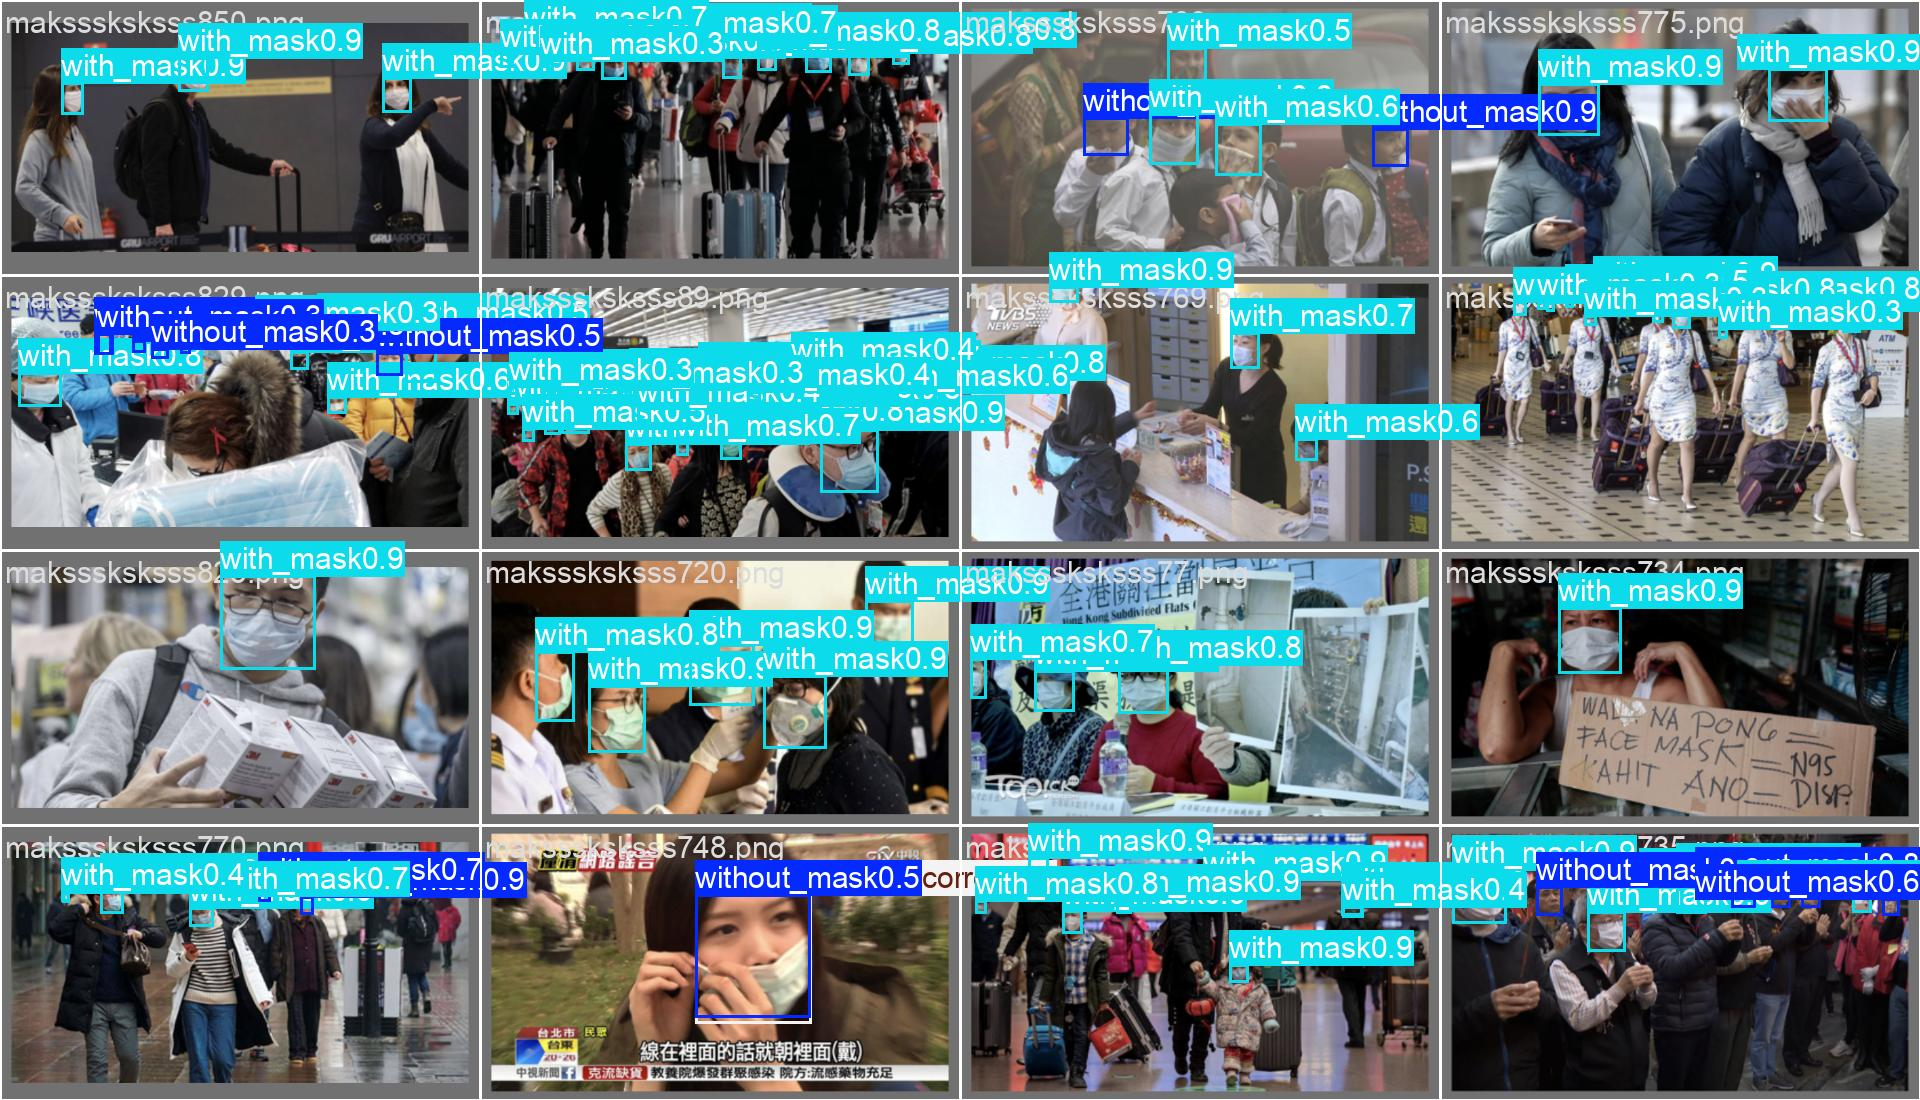


--- GROUND TRUTH LABELS (val_batch0_labels.jpg) ---


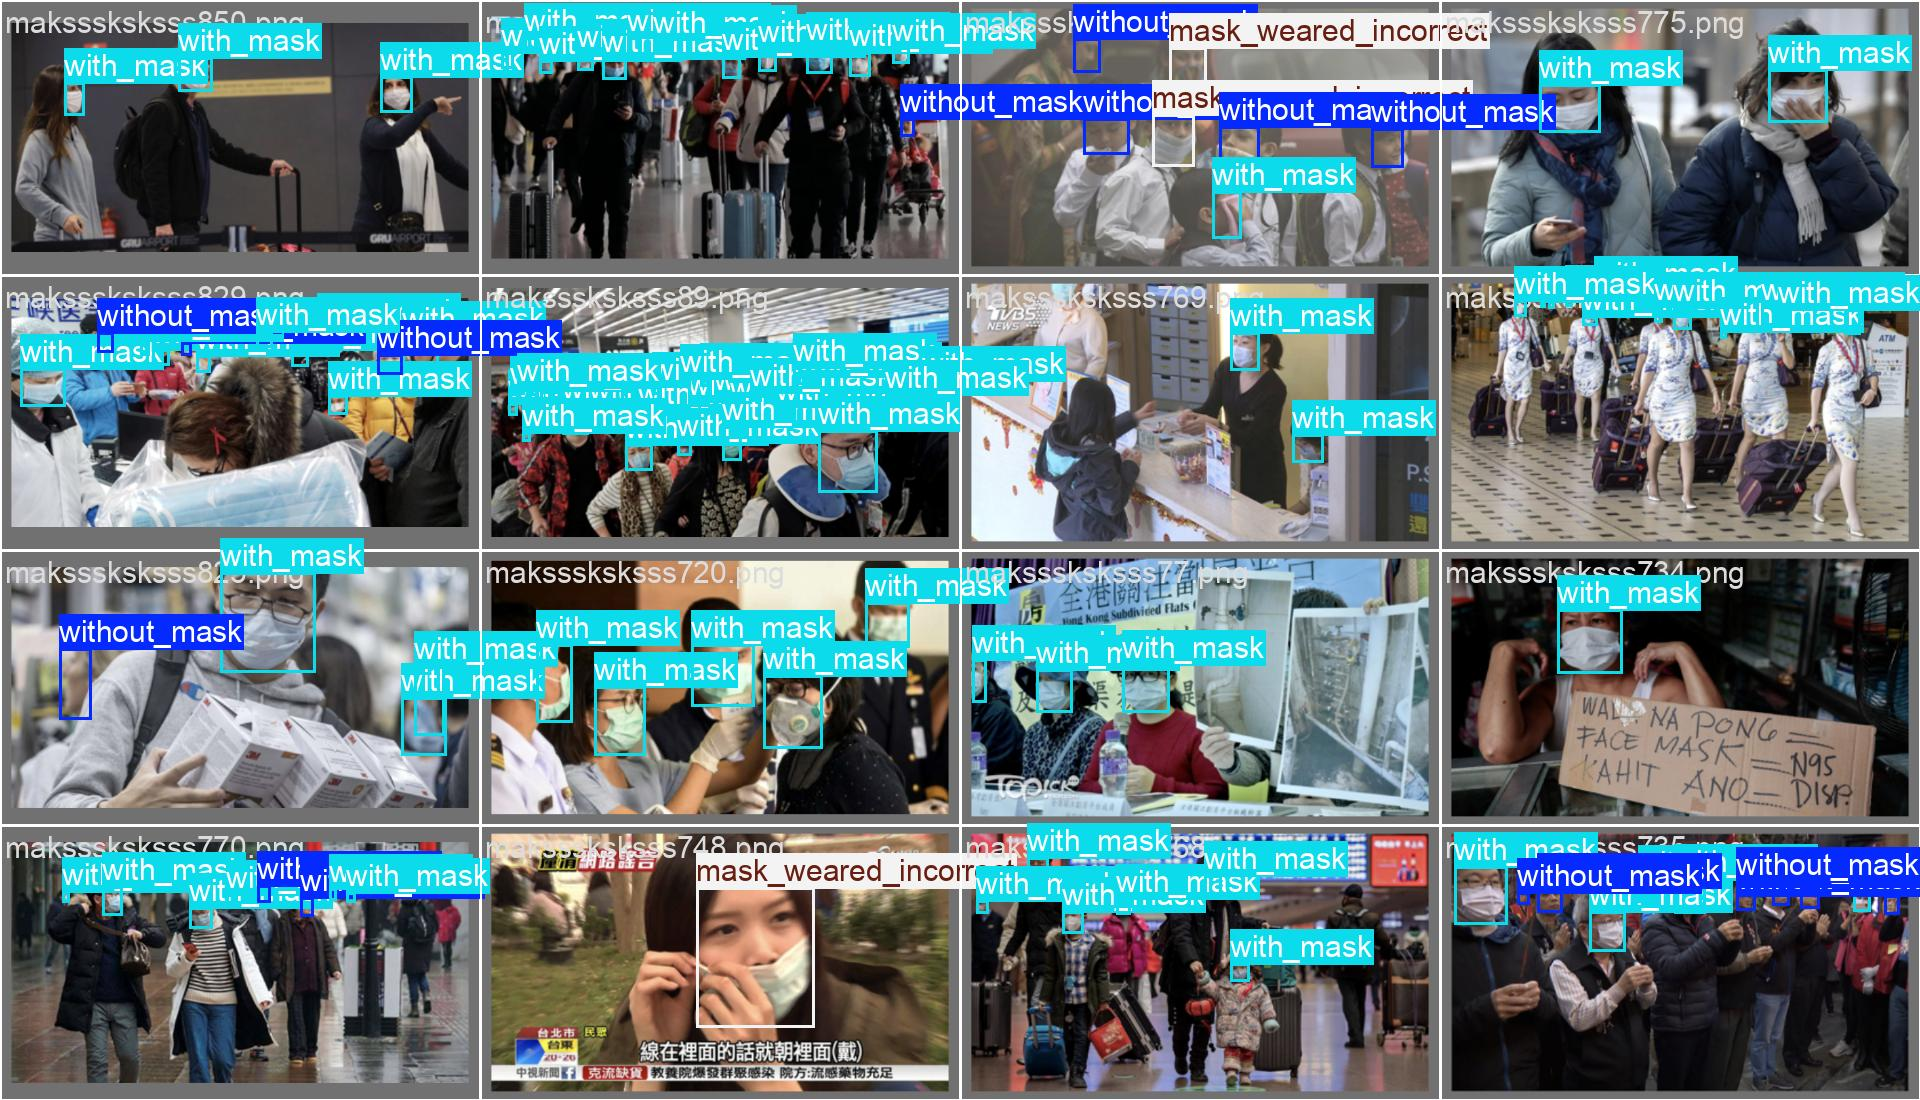

In [28]:
from IPython.display import Image, display

print("--- MODEL PREDICTIONS (val_batch0_pred.jpg) ---")
display(Image(filename='runs/detect/train-2/val_batch0_pred.jpg', width=800))

print("\n--- GROUND TRUTH LABELS (val_batch0_labels.jpg) ---")
display(Image(filename='runs/detect/train-2/val_batch0_labels.jpg', width=800))

--- TRAINING LOSS AND METRICS CURVES ---


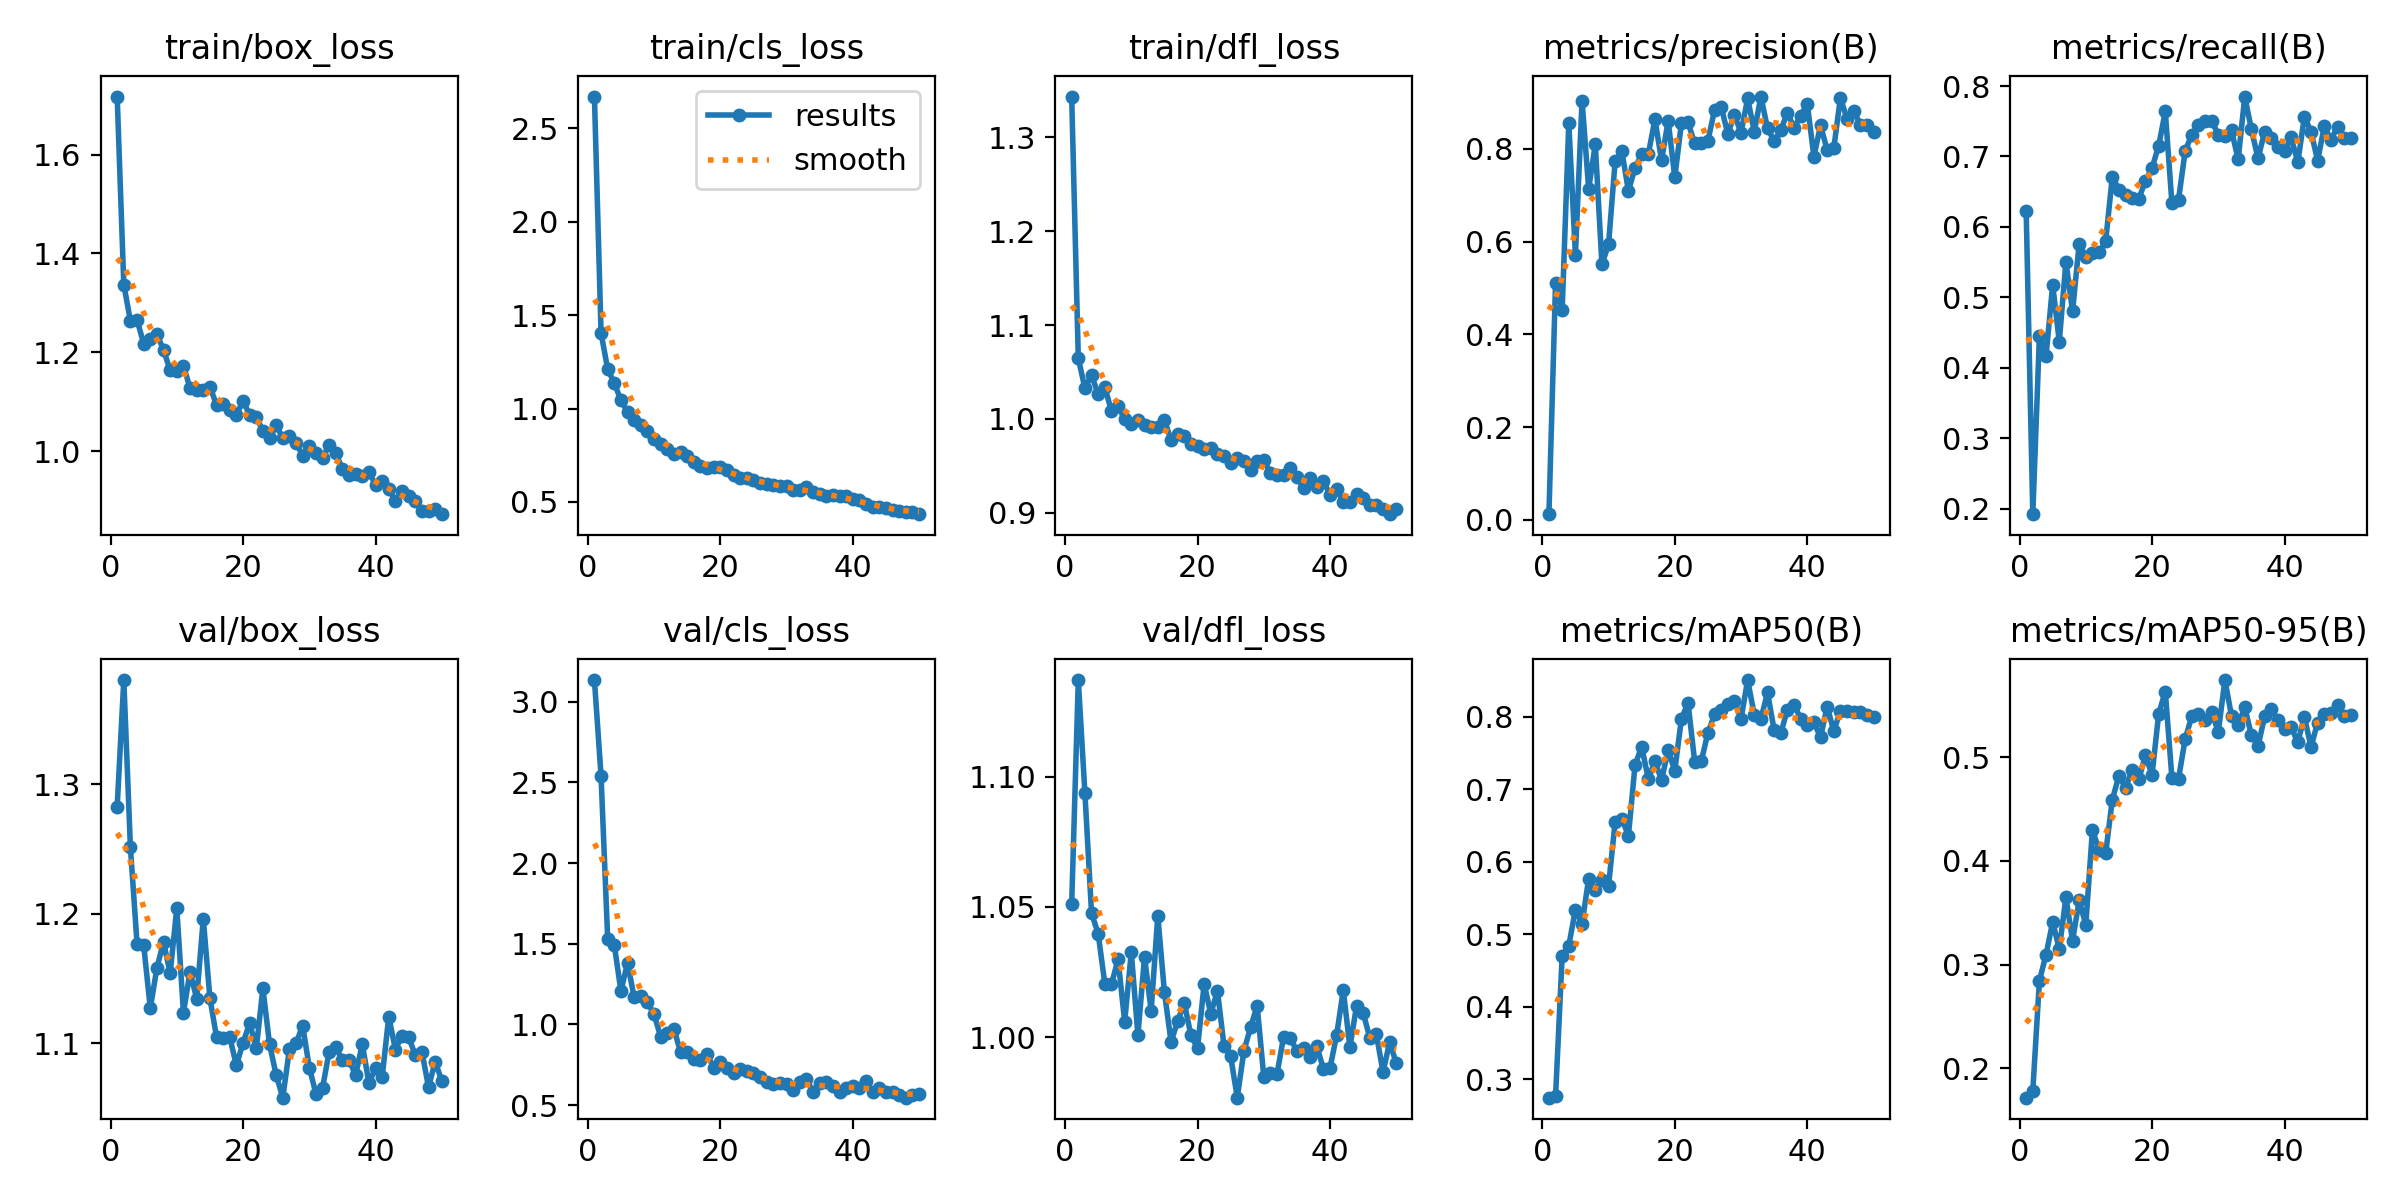


--- CONFUSION MATRIX ---


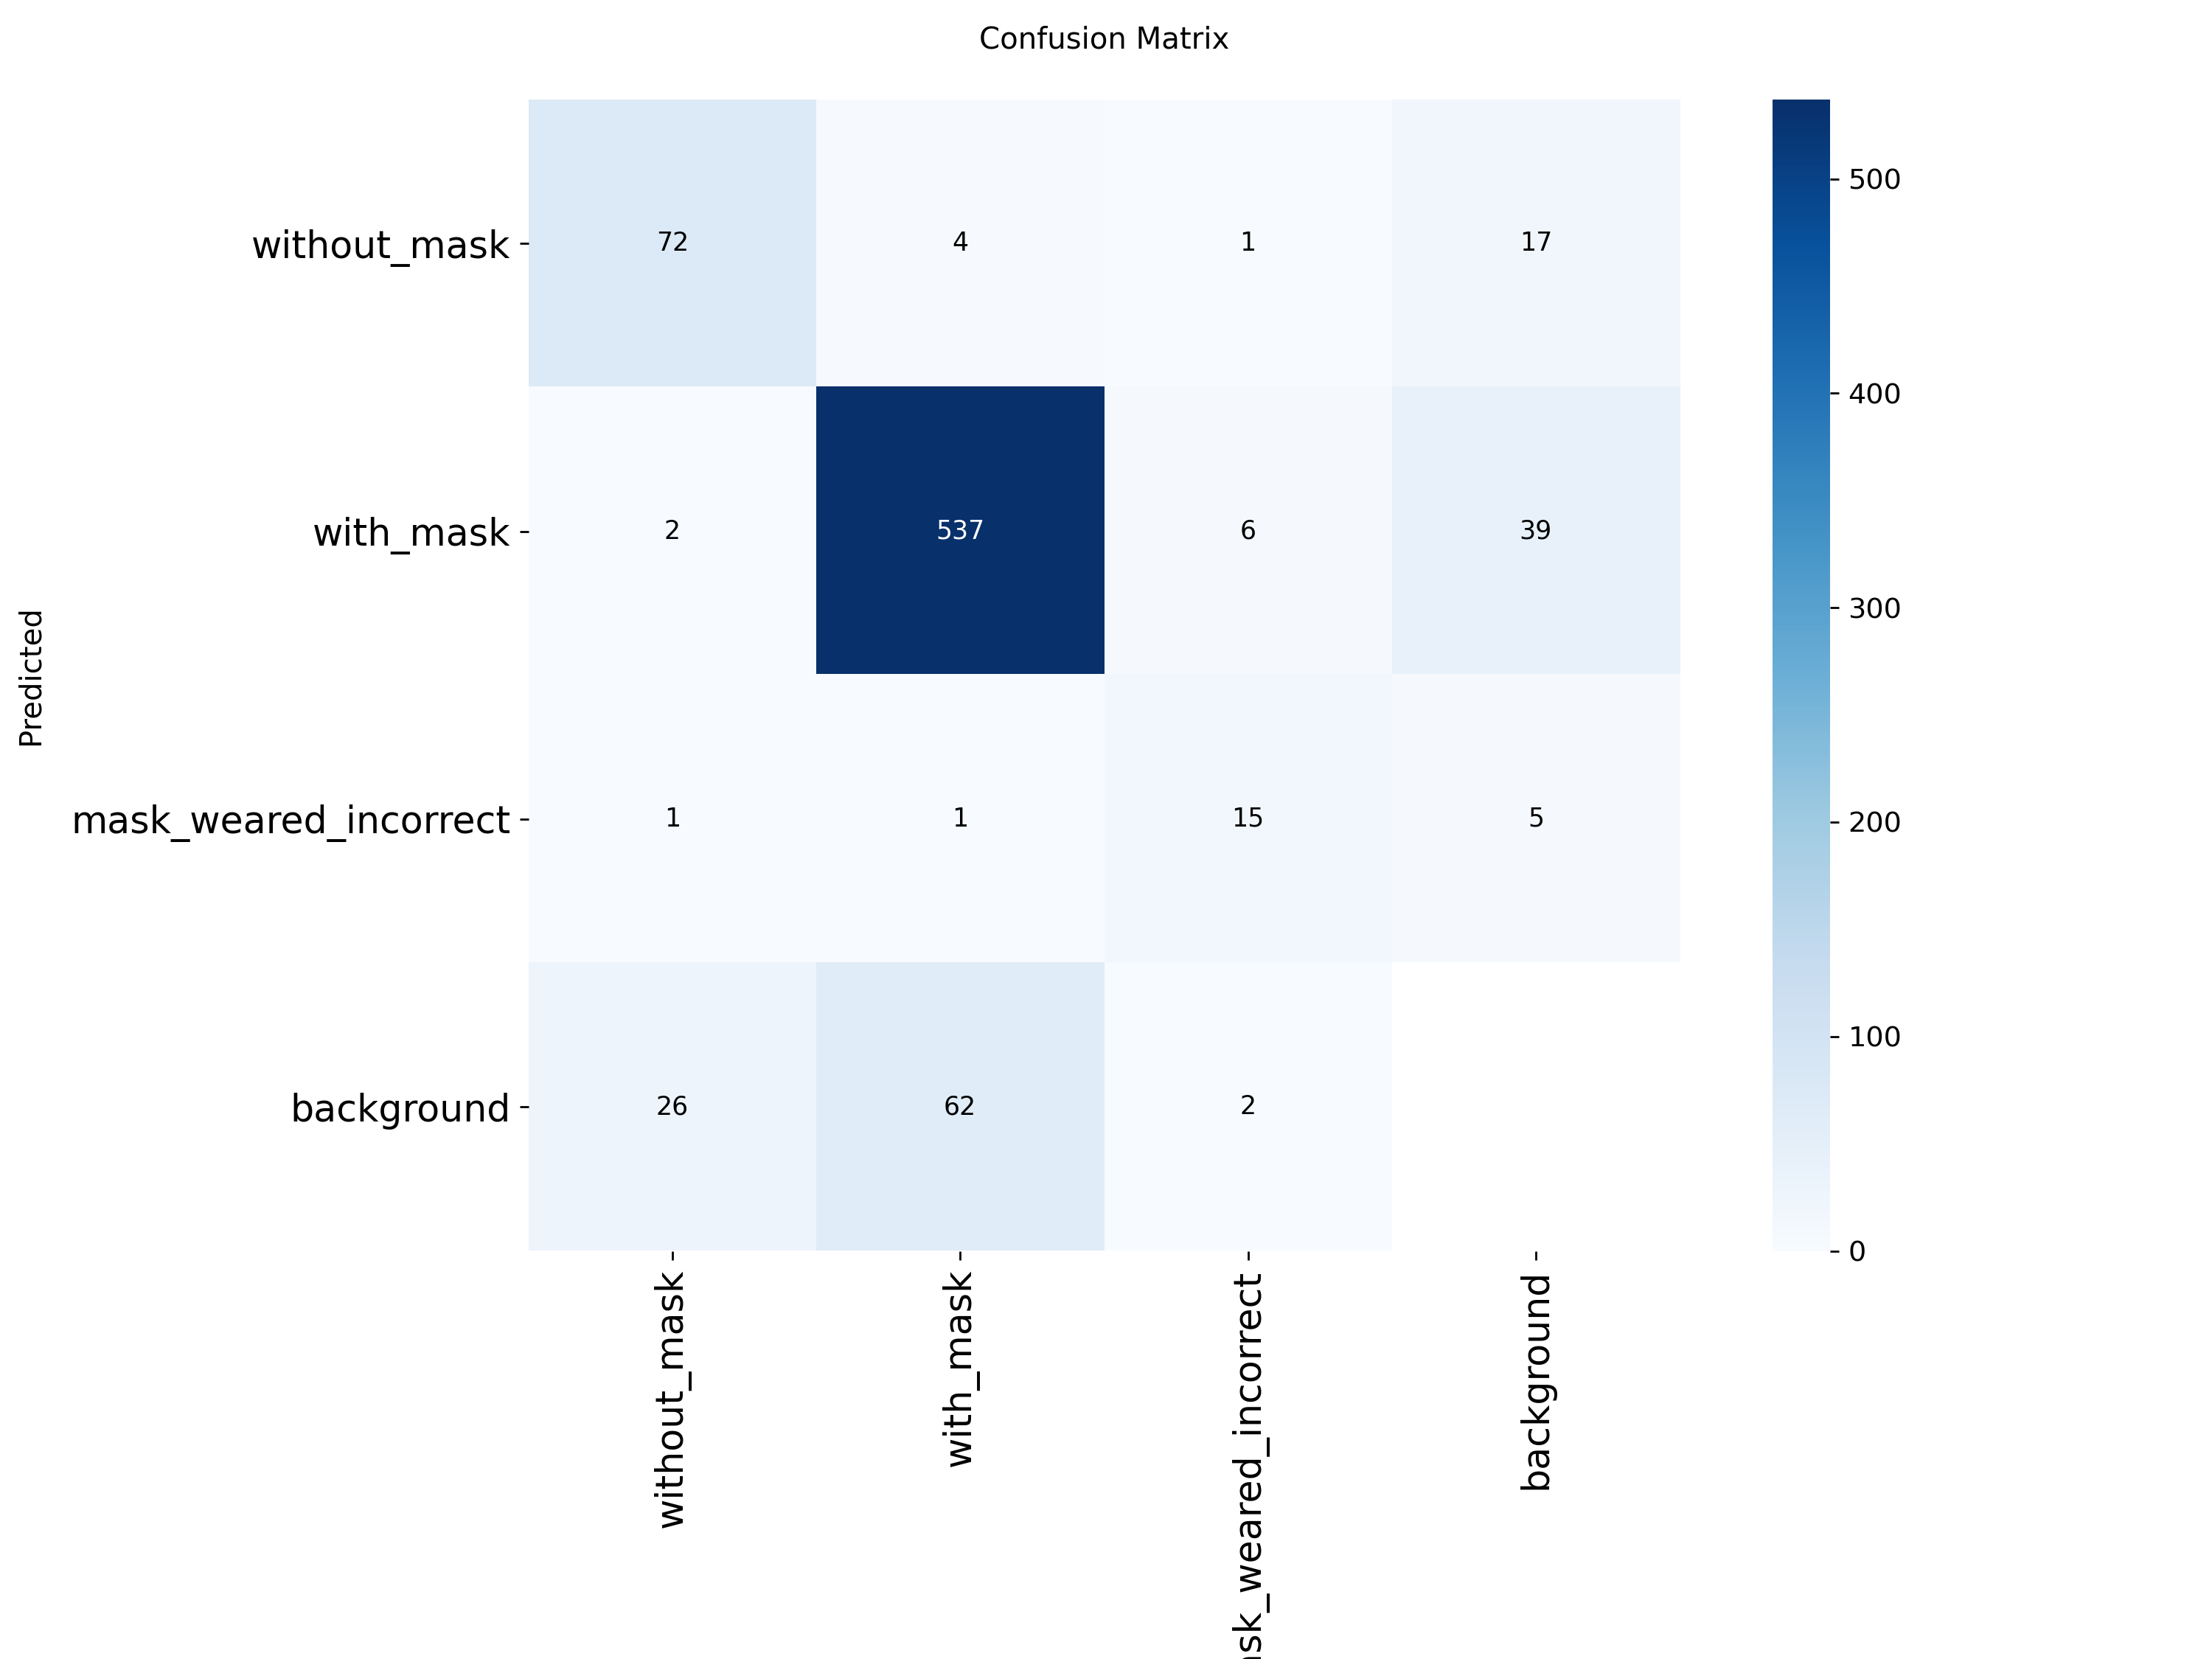

In [29]:
print("--- TRAINING LOSS AND METRICS CURVES ---")
display(Image(filename='runs/detect/train-2/results.png', width=800))

print("\n--- CONFUSION MATRIX ---")
display(Image(filename='runs/detect/train-2/confusion_matrix.png', width=600))